# King County Housing Market Analysis - By: Sophia Siraj

Dataset: King County House Sales (Kaggle, 2016)  
Data Source: Harlfoxem. (2016). House Sales in King County, USA [Dataset]. Kaggle. https://www.kaggle.com/datasets/harlfoxem/housesalesprediction

Description: This dataset contains house sale prices for King County, Washington (in the Seattle area), including homes sold between May 2014 and May 2015. I've split the data into two CSV files linked by a PropertyID key:
 - property_details.csv:  This has the physical characteristics of each home (bedrooms, bathrooms, square footage, floor group, etc.)
 - property_sales.csv: While this one is more information like sale price, quality grade, and location information

# Section 1: The Problem

Background: The housing market in Seattle is one of the most dynamic in the U.S. so understanding what factors drive the home prices is important for stakeholders like buyers, sellers, real estate agents and investors to understand. For this project, I'll be using descriptive analysis to learn more about the relationships between property characteristics and sales prices in King County, Washington. 


Research Questions: 

Q1): Do homes with more floors sell for higher prices on average? Is there a meaningful difference in sale price across floor group categories?

Q2): How does the number of bedrooms relate to sale price? Do homes with more bedrooms sell for higher prices on average?

Q3): Is there a meaningful difference in average sale price across grade groups (build and design quality ratings)? Do higher-grade homes command significantly higher prices?

# Section 2: The Data

In [1]:
# Reading and Merging the Two CSV files
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

df_details = pd.read_csv('kc_house property details.csv')
df_sales = pd.read_csv('kc_house property sales.csv')

print('kc_house property details.csv shape:', df_details.shape)
print('kc_house property sales.csv shape:', df_sales.shape)

print('\n--- Property_Details (first 5 rows) ---')
display(df_details.head())

print('\n--- Property_Sales (first 5 rows) ---')
display(df_sales.head())

kc_house property details.csv shape: (21613, 10)
kc_house property sales.csv shape: (21613, 9)

--- Property_Details (first 5 rows) ---


,PropertyID,Bedrooms,Bathrooms,Sqft_Living,Sqft_Lot,Floors,Floor_Group,Year_Built,Sqft_Above,Sqft_Basement
0,1,3,1.00,1180,5650,1.0,1 Floor,1955,1180,0
1,2,3,2.25,2570,7242,2.0,2 Floors,1951,2170,400
2,3,2,1.00,770,10000,1.0,1 Floor,1933,770,0
3,4,4,3.00,1960,5000,1.0,1 Floor,1965,1050,910
4,5,3,2.00,1680,8080,1.0,1 Floor,1987,1680,0



--- Property_Sales (first 5 rows) ---


,PropertyID,Price,GradeGroup,Grade,Waterfront_Label,View,Condition,Zipcode,Year_Renovated
0,1,221900,Average,7,No,0,3,98178,0
1,2,538000,Average,7,No,0,3,98125,1991
2,3,180000,Below Average,6,No,0,3,98028,0
3,4,604000,Average,7,No,0,5,98136,0
4,5,510000,Good,8,No,0,3,98074,0


In [2]:
#Then merge the 2 dataframes using the PropertyID key
df = pd.merge(df_details, df_sales, on = 'PropertyID')
print('Merged DataFrame shape:', df.shape)
print('\n--- Merged DataFrame (first 5 rows) ---')
display(df.head())

Merged DataFrame shape: (21613, 18)

--- Merged DataFrame (first 5 rows) ---


,PropertyID,Bedrooms,Bathrooms,Sqft_Living,Sqft_Lot,Floors,Floor_Group,Year_Built,Sqft_Above,Sqft_Basement,Price,GradeGroup,Grade,Waterfront_Label,View,Condition,Zipcode,Year_Renovated
0,1,3,1.00,1180,5650,1.0,1 Floor,1955,1180,0,221900,Average,7,No,0,3,98178,0
1,2,3,2.25,2570,7242,2.0,2 Floors,1951,2170,400,538000,Average,7,No,0,3,98125,1991
2,3,2,1.00,770,10000,1.0,1 Floor,1933,770,0,180000,Below Average,6,No,0,3,98028,0
3,4,4,3.00,1960,5000,1.0,1 Floor,1965,1050,910,604000,Average,7,No,0,5,98136,0
4,5,3,2.00,1680,8080,1.0,1 Floor,1987,1680,0,510000,Good,8,No,0,3,98074,0


In [3]:
#Checking the column data types
print('Column data types:')
print(df.dtypes)

#This makes sure that categorical columns are stored as strings
df['GradeGroup'] = df['GradeGroup'].astype(str)
df['Floor_Group'] = df['Floor_Group'].astype(str)
df['Waterfront_Label'] = df['Waterfront_Label'].astype(str)
df['GradeGroup']       = df['GradeGroup'].str.strip()
df['Floor_Group']      = df['Floor_Group'].str.strip()
df['Waterfront_Label'] = df['Waterfront_Label'].str.strip()

# And this is checking if there are any missing values
print('\nMissing values per column:')
print(df.isnull().sum())

Column data types:
PropertyID            int64
Bedrooms              int64
Bathrooms           float64
Sqft_Living           int64
Sqft_Lot              int64
Floors              float64
Floor_Group          object
Year_Built            int64
Sqft_Above            int64
Sqft_Basement         int64
Price                 int64
GradeGroup           object
Grade                 int64
Waterfront_Label     object
View                  int64
Condition             int64
Zipcode               int64
Year_Renovated        int64
dtype: object

Missing values per column:
PropertyID          0
Bedrooms            0
Bathrooms           0
Sqft_Living         0
Sqft_Lot            0
Floors              0
Floor_Group         0
Year_Built          0
Sqft_Above          0
Sqft_Basement       0
Price               0
GradeGroup          0
Grade               0
Waterfront_Label    0
View                0
Condition           0
Zipcode             0
Year_Renovated      0
dtype: int64


In [4]:
#This'll create a Bedroom_Group column for a grouped analysis (4 categories)
def bedroom_group(b):
    if b <= 2:
        return '1-2 Bedrooms'
    elif b == 3:
        return '3 Bedrooms'
    elif b == 4:
        return '4 Bedrooms'
    else:
        return '5+ Bedrooms'

df['Bedroom_Group'] = df['Bedrooms'].apply(bedroom_group)

print('Bedroom_Group value counts:')
print(df['Bedroom_Group'].value_counts())

Bedroom_Group value counts:
Bedroom_Group
3 Bedrooms      9824
4 Bedrooms      6882
1-2 Bedrooms    2972
5+ Bedrooms     1935
Name: count, dtype: int64


2.3: Basic Statistical Summaries using Loops (these are used to automatically generate descriptive summaries for all quantitative and qualitative columns)

In [5]:
# This will help identify quantitative and qualitative columns automatically
quant_cols = df.select_dtypes('number').columns.tolist()
qual_cols  = df.select_dtypes('object').columns.tolist()

# This removes the PropertyID column because it's an identifier, not a meaningful numeric variable
quant_cols = [c for c in quant_cols if c != 'PropertyID']

print('Quantitative columns:', quant_cols)
print('Qualitative columns: ', qual_cols)

Quantitative columns: ['Bedrooms', 'Bathrooms', 'Sqft_Living', 'Sqft_Lot', 'Floors', 'Year_Built', 'Sqft_Above', 'Sqft_Basement', 'Price', 'Grade', 'View', 'Condition', 'Zipcode', 'Year_Renovated']
Qualitative columns:  ['Floor_Group', 'GradeGroup', 'Waterfront_Label', 'Bedroom_Group']


In [6]:
# This loop is used for the descriptive summaries for all quantitative columns
print('=' * 60)
print('QUANTITATIVE COLUMN SUMMARIES')
print('=' * 60)

for col in quant_cols:
    print(f'\n--- {col} ---')
    print(f'  Count:  {df[col].count()}')
    print(f'  Mean:   {df[col].mean():.2f}')
    print(f'  Median: {df[col].median():.2f}')
    print(f'  Std:    {df[col].std():.2f}')
    print(f'  Min:    {df[col].min():.2f}')
    print(f'  Max:    {df[col].max():.2f}')

QUANTITATIVE COLUMN SUMMARIES

--- Bedrooms ---
  Count:  21613
  Mean:   3.37
  Median: 3.00
  Std:    0.93
  Min:    0.00
  Max:    33.00

--- Bathrooms ---
  Count:  21613
  Mean:   2.11
  Median: 2.25
  Std:    0.77
  Min:    0.00
  Max:    8.00

--- Sqft_Living ---
  Count:  21613
  Mean:   2079.90
  Median: 1910.00
  Std:    918.44
  Min:    290.00
  Max:    13540.00

--- Sqft_Lot ---
  Count:  21613
  Mean:   15106.97
  Median: 7618.00
  Std:    41420.51
  Min:    520.00
  Max:    1651359.00

--- Floors ---
  Count:  21613
  Mean:   1.49
  Median: 1.50
  Std:    0.54
  Min:    1.00
  Max:    3.50

--- Year_Built ---
  Count:  21613
  Mean:   1971.01
  Median: 1975.00
  Std:    29.37
  Min:    1900.00
  Max:    2015.00

--- Sqft_Above ---
  Count:  21613
  Mean:   1788.39
  Median: 1560.00
  Std:    828.09
  Min:    290.00
  Max:    9410.00

--- Sqft_Basement ---
  Count:  21613
  Mean:   291.51
  Median: 0.00
  Std:    442.58
  Min:    0.00
  Max:    4820.00

--- Price ---
  Cou

In [7]:
# This loop is used for the frequency counts for all qualitative columns
print('=' * 60)
print('QUALITATIVE COLUMN SUMMARIES')
print('=' * 60)

for col in qual_cols:
    print(f'\n--- {col} ---')
    print(df[col].value_counts())

QUALITATIVE COLUMN SUMMARIES

--- Floor_Group ---
Floor_Group
1 Floor        10680
2 Floors        8241
1.5 Floors      1910
2.5+ Floors      782
Name: count, dtype: int64

--- GradeGroup ---
GradeGroup
Average          8981
Good             8683
Below Average    2280
Excellent        1636
Low                33
Name: count, dtype: int64

--- Waterfront_Label ---
Waterfront_Label
No     21450
Yes      163
Name: count, dtype: int64

--- Bedroom_Group ---
Bedroom_Group
3 Bedrooms      9824
4 Bedrooms      6882
1-2 Bedrooms    2972
5+ Bedrooms     1935
Name: count, dtype: int64


2.4: More Exploratory Summaries

In [8]:
#This defines category orders (which are the logical display orders for all categorical columns)
grade_order = ['Low', 'Below Average', 'Average', 'Good', 'Excellent']
floor_order = ['1 Floor', '1.5 Floors', '2 Floors', '2.5+ Floors']
bed_order   = ['1-2 Bedrooms', '3 Bedrooms', '4 Bedrooms', '5+ Bedrooms']
water_order = ['No', 'Yes']

In [9]:
# These are some GroupBy summaries

# Average price by GradeGroup
print('Average Sale Price by Grade Group:')
display(
    df.groupby('GradeGroup')['Price']
    .mean().reindex(grade_order).round(2).to_frame()
)

# Average price and sqft_living by Floor_Group
print('Average Price and Sqft_Living by Floor Group:')
display(
    df.groupby('Floor_Group')[['Price', 'Sqft_Living']]
    .mean().reindex(floor_order).round(2)
)

# Average price by Waterfront_Label
print('Average Sale Price by Waterfront Status:')
display(
    df.groupby('Waterfront_Label')['Price']
    .mean().reindex(water_order).round(2).to_frame()
)

Average Sale Price by Grade Group:


,Price
GradeGroup,
Low,211395.45
Below Average,296252.20
Average,402590.26
Good,612319.19
Excellent,1257984.86


Average Price and Sqft_Living by Floor Group:


,Price,Sqft_Living
Floor_Group,,
1 Floor,442180.63,1731.85
1.5 Floors,558980.64,1907.88
2 Floors,648891.16,2571.28
2.5+ Floors,684489.45,2075.18


Average Sale Price by Waterfront Status:


,Price
Waterfront_Label,
No,531563.60
Yes,1661876.02


In [10]:
# These are some pivot tables

# Pivot table for average Price and Sqft_Living by GradeGroup
pivot1 = df.pivot_table(
    values=['Price', 'Sqft_Living'],
    index='GradeGroup',
    aggfunc='mean'
).reindex(grade_order).round(2)

print('Pivot Table: Average Price and Living Area by Grade Group')
display(pivot1)

# Pivot table for average Price by GradeGroup and Floor_Group
pivot2 = df.pivot_table(
    values='Price',
    index='GradeGroup',
    columns='Floor_Group',
    aggfunc='mean'
).reindex(grade_order).round(2)

print('Pivot Table: Average Price by Grade Group and Floor Group')
display(pivot2)

Pivot Table: Average Price and Living Area by Grade Group


,Price,Sqft_Living
GradeGroup,,
Low,211395.45,643.45
Below Average,296252.20,1169.46
Average,402590.26,1689.40
Good,612319.19,2390.56
Excellent,1257984.86,3872.57


Pivot Table: Average Price by Grade Group and Floor Group


Floor_Group,1 Floor,1.5 Floors,2 Floors,2.5+ Floors
GradeGroup,,,,
Low,212775.81,190000.00,NaN,NaN
Below Average,288994.52,333778.01,300895.62,361250.00
Average,390574.93,503890.61,386962.93,398611.53
Good,603435.31,749361.73,605977.70,587063.58
Excellent,1319362.05,1390090.22,1216387.10,1657705.87


In [11]:
# Some crosstabs

# CrossTab: Bedroom Group vs GradeGroup
print('CrossTab: Bedroom Group vs Grade Group')
display(pd.crosstab(df['Bedroom_Group'], df['GradeGroup']))

# CrossTab: Bedroom Group vs Floor Group
print('CrossTab: Bedroom Group vs Floor Group')
display(pd.crosstab(df['Bedroom_Group'], df['Floor_Group']))

CrossTab: Bedroom Group vs Grade Group


GradeGroup,Average,Below Average,Excellent,Good,Low
Bedroom_Group,,,,,
1-2 Bedrooms,1263,1053,28,596,32
3 Bedrooms,4917,916,362,3628,1
4 Bedrooms,2177,254,906,3545,0
5+ Bedrooms,624,57,340,914,0


CrossTab: Bedroom Group vs Floor Group


Floor_Group,1 Floor,1.5 Floors,2 Floors,2.5+ Floors
Bedroom_Group,,,,
1-2 Bedrooms,2117,203,515,137
3 Bedrooms,5455,786,3118,465
4 Bedrooms,2383,698,3682,119
5+ Bedrooms,725,223,926,61


In [12]:
#This is a correlation analysis using a correlation matric for key numeric variables
corr_cols = ['Price', 'Sqft_Living', 'Bedrooms', 'Bathrooms',
             'Sqft_Above', 'Year_Built', 'Sqft_Lot', 'Floors']
print('Correlation Matrix (key numeric variables):')
display(df[corr_cols].corr().round(3))

Correlation Matrix (key numeric variables):


,Price,Sqft_Living,Bedrooms,Bathrooms,Sqft_Above,Year_Built,Sqft_Lot,Floors
Price,1.000,0.702,0.308,0.525,0.606,0.054,0.090,0.257
Sqft_Living,0.702,1.000,0.577,0.755,0.877,0.318,0.173,0.354
Bedrooms,0.308,0.577,1.000,0.516,0.478,0.154,0.032,0.175
Bathrooms,0.525,0.755,0.516,1.000,0.685,0.506,0.088,0.501
Sqft_Above,0.606,0.877,0.478,0.685,1.000,0.424,0.184,0.524
Year_Built,0.054,0.318,0.154,0.506,0.424,1.000,0.053,0.489
Sqft_Lot,0.090,0.173,0.032,0.088,0.184,0.053,1.000,-0.005
Floors,0.257,0.354,0.175,0.501,0.524,0.489,-0.005,1.000


Now this section includes multiple exploratory plots

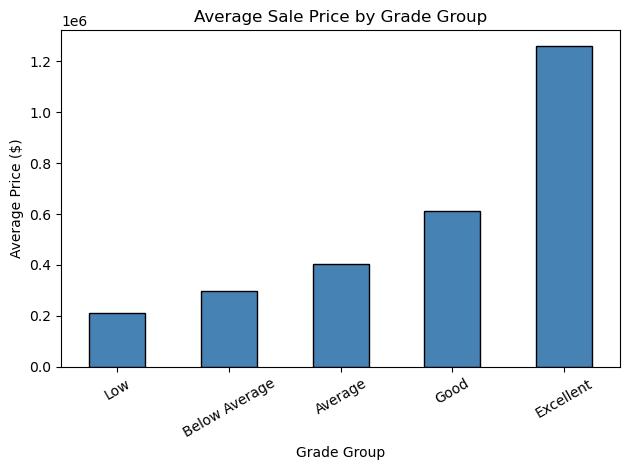

In [13]:
# Bar chart: average price by GradeGroup
df.groupby('GradeGroup')['Price'].mean().reindex(grade_order).plot(
    kind='bar', color='steelblue', edgecolor='black'
)
plt.title('Average Sale Price by Grade Group')
plt.xlabel('Grade Group')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

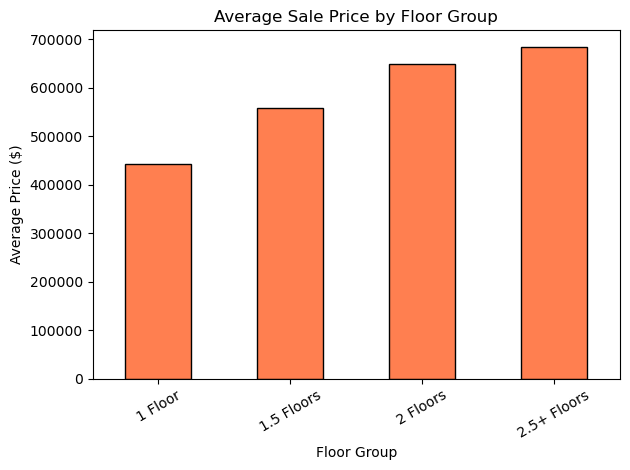

In [14]:
# Bar chart: average price by Floor Group
df.groupby('Floor_Group')['Price'].mean().reindex(floor_order).plot(
    kind='bar', color='coral', edgecolor='black'
)
plt.title('Average Sale Price by Floor Group')
plt.xlabel('Floor Group')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

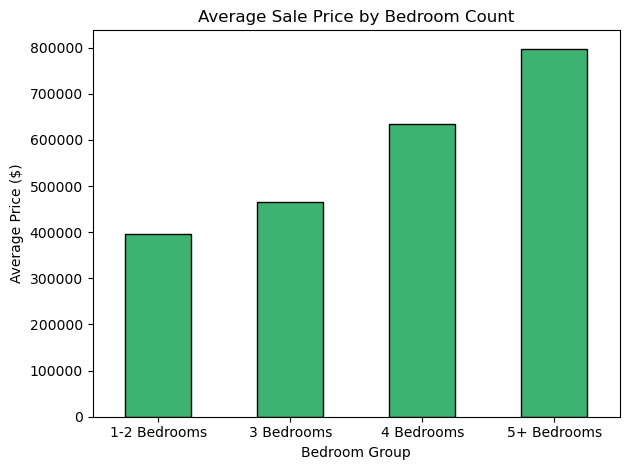

In [15]:
# Bar chart: average price by Bedroom Group
df.groupby('Bedroom_Group')['Price'].mean().reindex(bed_order).plot(
    kind='bar', color='mediumseagreen', edgecolor='black'
)
plt.title('Average Sale Price by Bedroom Count')
plt.xlabel('Bedroom Group')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

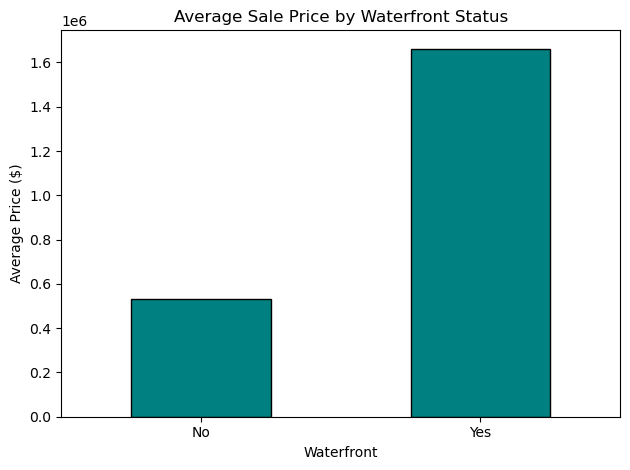

In [16]:
# Bar chart: average price by Waterfront Status
df.groupby('Waterfront_Label')['Price'].mean().reindex(water_order).plot(
    kind='bar', color='teal', edgecolor='black'
)
plt.title('Average Sale Price by Waterfront Status')
plt.xlabel('Waterfront')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

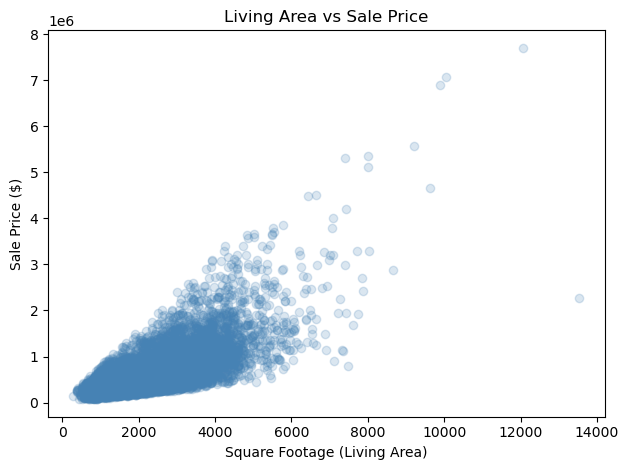

In [17]:
# Scatter plot: Sqft_Living vs Price
plt.scatter(df['Sqft_Living'], df['Price'], alpha=0.2, color='steelblue')
plt.title('Living Area vs Sale Price')
plt.xlabel('Square Footage (Living Area)')
plt.ylabel('Sale Price ($)')
plt.tight_layout()
plt.show()

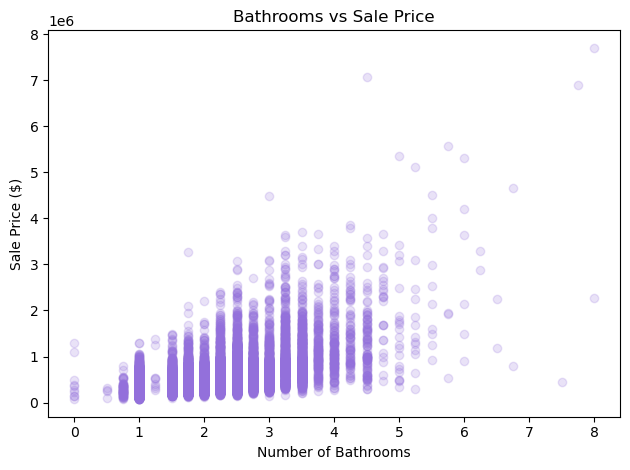

In [18]:
# Scatter plot: Bathrooms vs Price
plt.scatter(df['Bathrooms'], df['Price'], alpha=0.2, color='mediumpurple')
plt.title('Bathrooms vs Sale Price')
plt.xlabel('Number of Bathrooms')
plt.ylabel('Sale Price ($)')
plt.tight_layout()
plt.show()

# Section 3: The Analysis

Research Question 1: Do homes with more floors sell for higher prices on average? Is there a meaningful difference in sale price across floor group categories?

In [19]:
# RQ1 Analysis: Average Price and Sqft_Living grouped by Floor_Group
print('RQ1: Average Sale Price and Living Area by Floor Group')
print('=' * 60)

rq1_summary = df.groupby('Floor_Group')[['Price', 'Sqft_Living']].agg(
    ['count', 'mean', 'median', 'std']
).reindex(floor_order).round(2)

display(rq1_summary)

RQ1: Average Sale Price and Living Area by Floor Group


Price                                 Sqft_Living           \
             count       mean    median        std       count     mean   
Floor_Group                                                               
1 Floor      10680  442180.63  390000.0  264003.24       10680  1731.85   
1.5 Floors    1910  558980.64  524475.0  303541.33        1910  1907.88   
2 Floors      8241  648891.16  542950.0  433937.66        8241  2571.28   
2.5+ Floors    782  684489.45  527600.0  535780.44         782  2075.18   

                              
             median      std  
Floor_Group                   
1 Floor      1630.0   703.58  
1.5 Floors   1760.0   698.54  
2 Floors     2440.0   954.71  
2.5+ Floors  1600.0  1219.75

In [20]:
# CrossTab: Floor Group vs GradeGroup for additional context
print('CrossTab: Floor Group vs Grade Group')
display(pd.crosstab(df['Floor_Group'], df['GradeGroup']))

CrossTab: Floor Group vs Grade Group


GradeGroup,Average,Below Average,Excellent,Good,Low
Floor_Group,,,,,
1 Floor,5916,1864,189,2680,31
1.5 Floors,1006,349,46,507,2
2 Floors,1943,65,1309,4924,0
2.5+ Floors,116,2,92,572,0


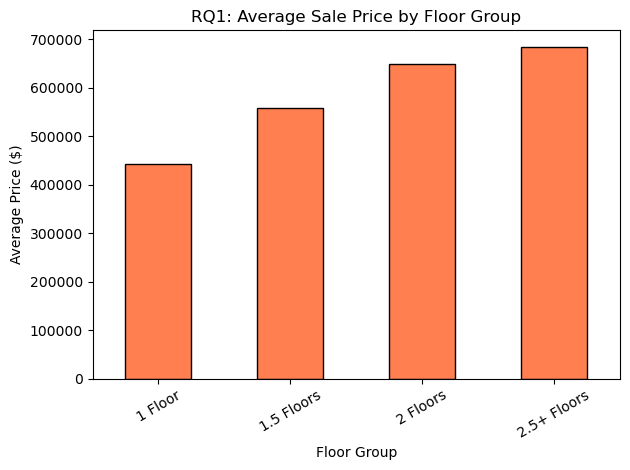

In [21]:
# Bar chart for RQ1
df.groupby('Floor_Group')['Price'].mean().reindex(floor_order).plot(
    kind='bar', color='coral', edgecolor='black'
)
plt.title('RQ1: Average Sale Price by Floor Group')
plt.xlabel('Floor Group')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

RQ1 Conclusion:
The analysis shows a clear positive relationship between number of floors and average sale price. Homes with 2.5+ floors have the highest average price, followed by 2-floor, 1.5-floor, and 1-floor homes respectively. This pattern makes sense since multi-story homes tend to have more total living space and are often built with higher-quality construction, both of which would drive up price. The crosstab also reveals that higher-floor homes are more likely to fall into the Good or Excellent grade groups, suggesting a relationship between floors, grade, and price. A future ANOVA test will confirm whether these price differences across floor groups are statistically significant.

Research Question 2: How does the number of bedrooms relate to sale price? Do homes with more bedrooms sell for higher prices on average?

In [22]:
# RQ2 Analysis: Average Price grouped by Bedroom_Group
print('RQ2: Average Sale Price by Bedroom Group')
print('=' * 55)

rq2_summary = df.groupby('Bedroom_Group')['Price'].agg(
    Count='count',
    Mean='mean',
    Median='median',
    Std='std',
    Min='min',
    Max='max'
).reindex(bed_order).round(2)

display(rq2_summary)

RQ2: Average Sale Price by Bedroom Group


,Count,Mean,Median,Std,Min,Max
Bedroom_Group,,,,,,
1-2 Bedrooms,2972,395801.85,365000.0,197131.82,75000,3278000
3 Bedrooms,9824,466232.08,413000.0,262469.77,82000,3800000
4 Bedrooms,6882,635419.50,549997.5,388594.44,100000,4489000
5+ Bedrooms,1935,797612.90,627000.0,633170.34,133000,7700000


In [23]:
# Pivot table: average Price by Bedroom_Group and GradeGroup
print('Pivot Table: Average Price by Bedroom Group and Grade Group')
pivot_rq2 = df.pivot_table(
    values='Price',
    index='Bedroom_Group',
    columns='GradeGroup',
    aggfunc='mean'
).reindex(bed_order).round(2)
display(pivot_rq2)

Pivot Table: Average Price by Bedroom Group and Grade Group


GradeGroup,Average,Below Average,Excellent,Good,Low
Bedroom_Group,,,,,
1-2 Bedrooms,410197.29,293204.56,1129393.54,521988.99,211595.31
3 Bedrooms,381316.94,288503.16,1087320.53,564290.14,205000.00
4 Bedrooms,427675.30,320847.99,1198970.11,641507.92,NaN
5+ Bedrooms,467306.80,367479.65,1607538.98,748656.37,NaN


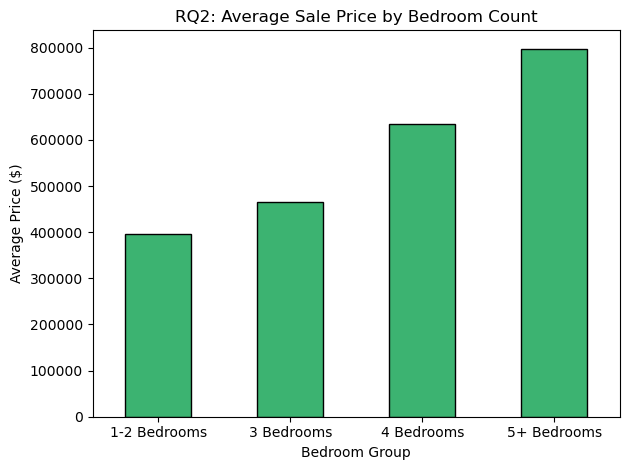

In [24]:
# Bar chart for RQ2
df.groupby('Bedroom_Group')['Price'].mean().reindex(bed_order).plot(
    kind='bar', color='mediumseagreen', edgecolor='black'
)
plt.title('RQ2: Average Sale Price by Bedroom Count')
plt.xlabel('Bedroom Group')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

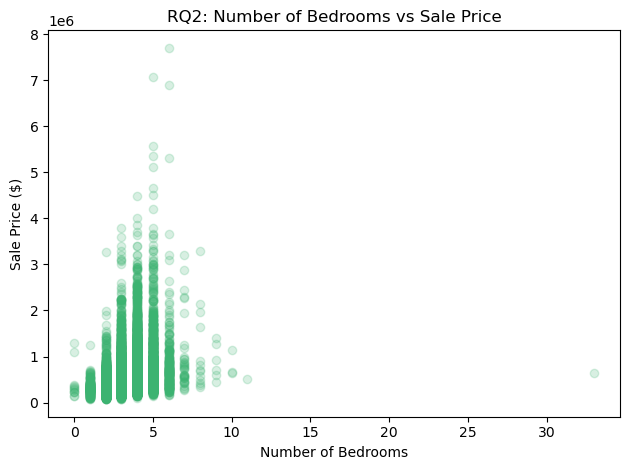

In [25]:
# Scatter: Bedrooms vs Price
plt.scatter(df['Bedrooms'], df['Price'], alpha=0.2, color='mediumseagreen')
plt.title('RQ2: Number of Bedrooms vs Sale Price')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Sale Price ($)')
plt.tight_layout()
plt.show()

RQ2 Conclusion: 
The data shows a consistent upward trend in average sale price as bedroom count increases across all four groups: 1-2 bedrooms averaged 395,802 dollars, 3 bedrooms averaged 466,232, 4 bedrooms averaged 635,420, and 5+ bedrooms averaged 797,613. Unlike what might be expected, homes with 5+ bedrooms do not show a price dip. They actually command the highest average price of any group. However, the standard deviation for 5+ bedroom homes is also the highest 633,170, meaning prices in this group vary widely. The pivot table confirms that grade group still plays a major role within each bedroom category and that Excellent-grade homes command dramatically higher prices regardless of bedroom count. Overall, bedroom count has a strong positive relationship with sale price, though it works best as a predictor in combination with other variables like grade and square footage.

Research Question 3: Is there a meaningful difference in average sale price across grade groups (build and design quality ratings)? Do higher-grade homes command significantly higher prices?

In [26]:
# RQ3 Analysis: Average Price grouped by GradeGroup
print('RQ3: Average Sale Price by Grade Group')
print('=' * 55)

rq3_summary = df.groupby('GradeGroup')['Price'].agg(
    Count='count',
    Mean='mean',
    Median='median',
    Std='std',
    Min='min',
    Max='max'
).reindex(grade_order).round(2)

display(rq3_summary)

RQ3: Average Sale Price by Grade Group


,Count,Mean,Median,Std,Min,Max
GradeGroup,,,,,,
Low,33,211395.45,205000.0,93536.03,75000,435000
Below Average,2280,296252.20,270000.0,123537.53,78000,1200000
Average,8981,402590.26,375000.0,155876.92,90000,2050000
Good,8683,612319.19,561600.0,272646.74,140000,3070000
Excellent,1636,1257984.86,1038500.0,706848.37,316000,7700000


In [27]:
# Pivot table: average Price by GradeGroup and Floor_Group
print('Pivot Table: Average Price by Grade Group and Floor Group')
pivot_rq3 = df.pivot_table(
    values='Price',
    index='GradeGroup',
    columns='Floor_Group',
    aggfunc='mean'
).reindex(grade_order).round(2)
display(pivot_rq3)

Pivot Table: Average Price by Grade Group and Floor Group


Floor_Group,1 Floor,1.5 Floors,2 Floors,2.5+ Floors
GradeGroup,,,,
Low,212775.81,190000.00,NaN,NaN
Below Average,288994.52,333778.01,300895.62,361250.00
Average,390574.93,503890.61,386962.93,398611.53
Good,603435.31,749361.73,605977.70,587063.58
Excellent,1319362.05,1390090.22,1216387.10,1657705.87


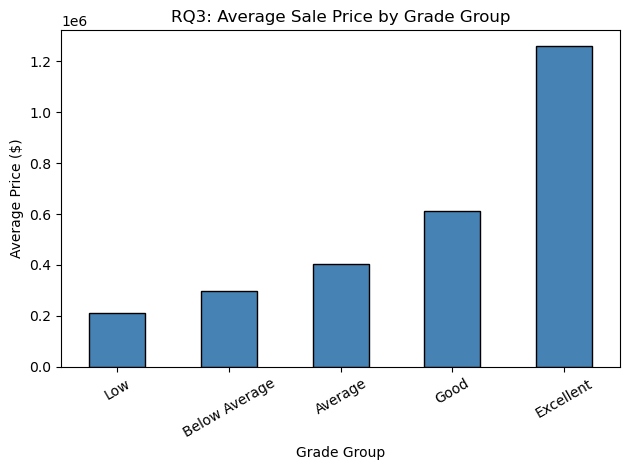

In [28]:
# Bar chart for RQ3
df.groupby('GradeGroup')['Price'].mean().reindex(grade_order).plot(
    kind='bar', color='steelblue', edgecolor='black'
)
plt.title('RQ3: Average Sale Price by Grade Group')
plt.xlabel('Grade Group')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

RQ3 Conclusion: 
The results clearly show that grade group is the strongest predictor of sale price among all variables explored in this project. There is a consistent, stepwise increase in average price from Low through Excellent grade groups, with Excellent-grade homes selling for dramatically more than Low or Below Average-grade homes. The pivot table confirms this pattern holds across all floor group categories as well, meaning grade has an independent effect on price regardless of how many floors a home has. A future ANOVA test will confirm whether these group differences are statistically significant.

# Section 4: Conclusion

This analysis of King County home sales data revealed several important patterns driving residential home prices including:

1. Floor count is positively associated with sale price since homes with more floors sell for more on average, likely because multi-story homes tend to have more total living space and higher-quality construction.

2. Bedroom count shows a consistent positive relationship with sale price across all groups, with 5+ bedroom homes actually commanding the highest average price of any bedroom group. However, the 5+ bedroom group also has the highest price variability, meaning individual homes in this category can range widely in value. Bedroom count is a useful but not standalone predictor of home value.

3. Grade group is the most powerful predictor of sale price in this dataset. Excellent-grade homes sell for dramatically more than Low or Below Average-grade homes. It's important to note that this pattern holds regardless of floor count or bedroom count.

Overall, grade group, living area (square footage), and floor count emerge as the most impactful variables in explaining King County home prices.

If I were to take this project, I would plan to: 
- T-test: Compare average sale prices between waterfront and non-waterfront properties to test whether the waterfront premium is statistically significant.
- ANOVA: Test whether mean sale prices differ significantly across all five grade groups (Low, Below Average, Average, Good, Excellent).
- Regression Analysis: Build a multiple regression model to predict Price from Sqft_Living, Bedrooms, Bathrooms, Floors, and Year_Built, quantifying how much each variable independently contributes to home value.
- Additional visualizations: Histograms of price distribution by grade group, box plots comparing price across floor groups, and a correlation heatmap of all numeric variables.

# Citations (APA Style)

Harlfoxem. (2016). House Sales in King County, USA [Data set]. 
Kaggle. https://www.kaggle.com/datasets/harlfoxem/housesalesprediction